# Multi-seed evaluation

`Adaptive_ETA_Prediction.ipynb` reports one random seed. With 200 test voyages and a stochastic RL agent, a single run is
noisy, so this notebook re-runs the same pipeline (the main notebook's own cells, found by their `Cell N:` header) with five
seeds and reports the mean and spread.

Every seed regenerates the synthetic data, retrains the DNN (early stopping on validation), retrains the Q-learning agent on
training voyages, and fits the two simple corrections on training voyages. All four methods are scored on the same 200
test voyages per seed. Gains are **paired** against the DNN from the same seed, because the absolute MAE moves by about
±16 minutes between seeds, more than any method's effect. Runtime: about 1 minute on a laptop CPU.

In [1]:
import contextlib, io, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nbformat

MAIN = "Adaptive_ETA_Prediction.ipynb"
SEEDS = [42, 1, 2, 3, 4]                                   # 42 is the main notebook's seed
CELLS = [1, 2, 3, 4, 5, 7, 8, 10, 11, 12, 13, 15]          # data -> DNN -> NLP -> agent -> evaluation (no plots/demo)


def run_pipeline(seed):
    # Execute the main notebook's own cells with a different seed and return its variables.
    src = [c.source for c in nbformat.read(MAIN, as_version=4).cells if c.cell_type == "code"]
    ns = {}
    real_savefig, real_show = plt.savefig, plt.show
    plt.savefig = lambda *a, **k: None                     # never overwrite the main notebook's figures
    plt.show = lambda *a, **k: plt.close("all")
    try:
        with contextlib.redirect_stdout(io.StringIO()):     # the pipeline's own prints are not needed here
            for n in CELLS:
                hits = [s for s in src if f"Cell {n}:" in s.splitlines()[0]]
                assert len(hits) == 1, f"Cell {n} not found exactly once in {MAIN}"
                s = hits[0]
                if n == 1:
                    assert "seed          = 42" in s
                    s = s.replace("seed          = 42", f"seed          = {seed}")
                exec(s, ns)
    finally:
        plt.savefig, plt.show = real_savefig, real_show
    return ns


rows = []
for seed in SEEDS:
    ns = run_pipeline(seed)
    rows.append({"seed": seed,
                 "DNN alone": ns["mae_base_eval"],
                 "+ constant bias (no text)": ns["mae_bias"],
                 "+ NLP + Q-learning": ns["mae_adap_eval"],
                 "+ NLP + linear correction": ns["mae_linear"],
                 "linear a": ns["lin_a"], "linear b": ns["lin_b"]})
    r = rows[-1]
    print(f"seed {seed:>2} | DNN {r['DNN alone']:.2f} | bias {r['+ constant bias (no text)']:.2f}"
          f" | Q-learning {r['+ NLP + Q-learning']:.2f} | linear {r['+ NLP + linear correction']:.2f}")

res = pd.DataFrame(rows)
os.makedirs("results", exist_ok=True)
res.to_csv("results/multi_seed_results.csv", index=False)
res.round(2)

C:\Users\riyan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


seed 42 | DNN 153.61 | bias 148.41 | Q-learning 156.47 | linear 134.22


seed  1 | DNN 129.97 | bias 124.14 | Q-learning 129.76 | linear 112.93


seed  2 | DNN 149.43 | bias 156.11 | Q-learning 143.14 | linear 149.16


seed  3 | DNN 175.91 | bias 172.97 | Q-learning 180.75 | linear 165.90


seed  4 | DNN 155.41 | bias 155.64 | Q-learning 158.13 | linear 145.13


,seed,DNN alone,+ constant bias (no text),+ NLP + Q-learning,+ NLP + linear correction,linear a,linear b
0,42,153.61,148.41,156.47,134.22,-0.09,0.10
1,1,129.97,124.14,129.76,112.93,-0.09,0.13
2,2,149.43,156.11,143.14,149.16,-0.08,0.11
3,3,175.91,172.97,180.75,165.90,-0.10,0.13
4,4,155.41,155.64,158.13,145.13,-0.07,0.13


## Results

MAE in minutes (lower is better), and each method's paired gain over the DNN from the same seed.

In [2]:
methods = ["DNN alone", "+ constant bias (no text)", "+ NLP + Q-learning", "+ NLP + linear correction"]
summary = res[methods].agg(["mean", "std"]).T.round(2)
summary.columns = ["MAE mean (min)", "MAE sd (min)"]
gains = pd.DataFrame({m: 100 * (res["DNN alone"] - res[m]) / res["DNN alone"] for m in methods[1:]})
gains.index = res["seed"]
display(summary)
display(gains.round(2).T.assign(mean=gains.mean().round(2), sd=gains.std().round(2)))
wins = int((res["+ NLP + linear correction"] < res["+ NLP + Q-learning"]).sum())
print(f"Linear correction beats Q-learning in {wins} of {len(res)} seeds.")
print(f"Linear correction learned on training voyages: a = {res['linear a'].mean():+.3f}, b = {res['linear b'].mean():+.3f} (mean over seeds)")

,MAE mean (min),MAE sd (min)
DNN alone,152.87,16.39
+ constant bias (no text),151.45,17.73
+ NLP + Q-learning,153.65,19.00
+ NLP + linear correction,141.47,19.60


seed,42,1,2,3,4,mean,sd
+ constant bias (no text),3.39,4.49,-4.47,1.67,-0.15,0.99,3.52
+ NLP + Q-learning,-1.86,0.16,4.21,-2.75,-1.75,-0.40,2.79
+ NLP + linear correction,12.62,13.11,0.18,5.69,6.62,7.64,5.37


Linear correction beats Q-learning in 4 of 5 seeds.
Linear correction learned on training voyages: a = -0.085, b = +0.120 (mean over seeds)


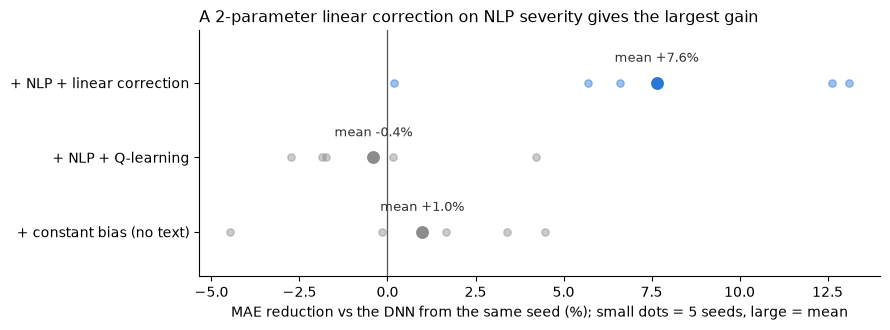

In [3]:
order = list(gains.columns)
fig, ax = plt.subplots(figsize=(9, 3.4))
for yi, name in enumerate(order):
    vals = gains[name].values
    colour = "#2a78d6" if "linear" in name else "#8c8c8c"
    ax.scatter(vals, np.full(len(vals), yi), s=28, color=colour, alpha=0.45, zorder=2)
    ax.scatter(vals.mean(), yi, s=110, color=colour, zorder=3, edgecolor="white", linewidth=1.2)
    ax.text(vals.mean(), yi + 0.28, f"mean {vals.mean():+.1f}%", ha="center", fontsize=9, color="#333333")
ax.axvline(0, color="#555555", lw=0.9)
ax.set_yticks(range(len(order)), order)
ax.set_ylim(-0.6, len(order) - 0.3)
ax.set_xlabel("MAE reduction vs the DNN from the same seed (%); small dots = 5 seeds, large = mean")
ax.set_title("A 2-parameter linear correction on NLP severity gives the largest gain", loc="left", fontsize=11.5)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
plt.tight_layout()
plt.savefig("figures/fig_multi_seed.png", dpi=170, bbox_inches="tight")
plt.show()

## Reading the results

* **The NLP severity signal is useful.** A two-parameter linear correction on it gives the largest and most consistent
  reduction in error.
* **Q-learning does not improve on the DNN on average.** The adjustment is one decision per voyage with no next state (a
  contextual bandit), so a direct regression on severity uses the signal better than five discrete actions over 210 states.
* **A constant correction without text** recovers only a small part of the gain, so the improvement comes from the text
  signal, not from fixing an overall bias.